In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# !pip install kaggle

KGAT_3f6352c63ce5e16e01e30085b623899a

# Data Curation

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username":"thantsintun",\r\n  "key":"KGAT_3f6352c63ce5e16e01e30085b623899a"\r\n}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d karagwaanntreasure/plant-disease-detection

Dataset URL: https://www.kaggle.com/datasets/karagwaanntreasure/plant-disease-detection
License(s): MIT
100% 534M/534M [00:05<00:00, 111MB/s]



## Unzipping

In [ ]:
!unzip plant-disease-detection.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-7476153023ce___YLCV_GCREC 2258.JPG  
  inflating: Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/092330d8-f6e9-48df-8525-cb391b8f

Check folders:

In [ ]:
import os
os.listdir('Dataset')

['Tomato_Early_blight',
 'Potato___Early_blight',
 'Tomato__Tomato_mosaic_virus',
 'Apple___healthy',
 'Potato___Late_blight',
 'Tomato_Late_blight',
 'Apple___Black_rot',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Potato___healthy',
 'Pepper__bell___Bacterial_spot',
 'Tomato_healthy',
 'Tomato__Target_Spot',
 'Apple___Apple_scab',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Pepper__bell___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Apple___Cedar_apple_rust',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Leaf_Mold',
 'Corn_(maize)___healthy']

# Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import numpy as np

# Load Dataset

Find correct dataset folder name first.

In [ ]:
import os

for root, dirs, files in os.walk("."):
    print(root)
    break

.


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset_path = "/content/Dataset"

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 35725 files belonging to 23 classes.
Using 28580 files for training.
Found 35725 files belonging to 23 classes.
Using 7145 files for validation.


In [ ]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## Data Exploration

View Class names

In [ ]:
class_names = train_data.class_names

print("Total Classes:", len(class_names))
print()

for i in enumerate(class_names):
  print(i)

Total Classes: 23

(0, 'Apple___Apple_scab')
(1, 'Apple___Black_rot')
(2, 'Apple___Cedar_apple_rust')
(3, 'Apple___healthy')
(4, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot')
(5, 'Corn_(maize)___Common_rust_')
(6, 'Corn_(maize)___Northern_Leaf_Blight')
(7, 'Corn_(maize)___healthy')
(8, 'Pepper__bell___Bacterial_spot')
(9, 'Pepper__bell___healthy')
(10, 'Potato___Early_blight')
(11, 'Potato___Late_blight')
(12, 'Potato___healthy')
(13, 'Tomato_Bacterial_spot')
(14, 'Tomato_Early_blight')
(15, 'Tomato_Late_blight')
(16, 'Tomato_Leaf_Mold')
(17, 'Tomato_Septoria_leaf_spot')
(18, 'Tomato_Spider_mites_Two_spotted_spider_mite')
(19, 'Tomato__Target_Spot')
(20, 'Tomato__Tomato_YellowLeaf__Curl_Virus')
(21, 'Tomato__Tomato_mosaic_virus')
(22, 'Tomato_healthy')


In [ ]:
len(train_data.class_names)

23

In [ ]:
len(val_data.class_names)

23

# Optimize Dataset

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)

# Data Augmentation

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

# Model Creating & Training

### Model 0 (Just random)

In [ ]:
model_0 = Sequential([
  layers.Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),

  layers.MaxPool2D(),

  layers.Conv2D(10, 3, activation='relu'),

  layers.MaxPool2D(),

  layers.Flatten(),

  layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_0.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │       670,703 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 671,893 (2.56 MB)

 Trainable params: 671,893 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_0.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_0 = model_0.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.2857 - loss: 12.1331 - val_accuracy: 0.3142 - val_loss: 2.3282
Epoch 2/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 39s 40ms/step - accuracy: 0.4751 - loss: 1.7893 - val_accuracy: 0.3302 - val_loss: 2.3125
Epoch 3/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.6140 - loss: 1.2862 - val_accuracy: 0.3467 - val_loss: 2.4425
Epoch 4/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 32s 35ms/step - accuracy: 0.6968 - loss: 0.9912 - val_accuracy: 0.3758 - val_loss: 2.9023
Epoch 5/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.7559 - loss: 0.7996 - val_accuracy: 0.3868 - val_loss: 3.3375
Epoch 6/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.8102 - loss: 0.6796 - val_accuracy: 0.3986 - val_loss: 4.0306
Epoch 7/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step - accuracy: 0.8427 - loss: 0.5587 - val_accuracy: 0.4460 - val_loss: 4.8448
Epoch 8/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step - accuracy: 0.8596 - loss: 0.4947 -

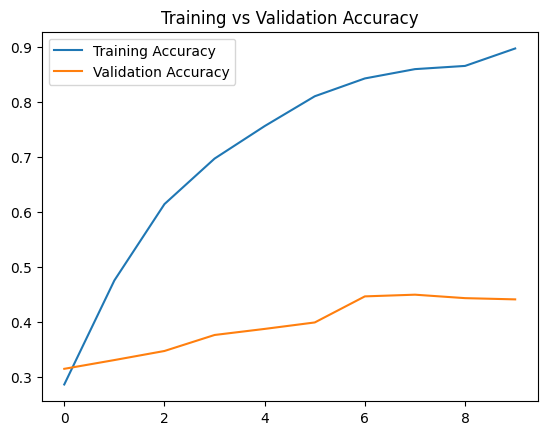

In [ ]:
acc = history_0.history['accuracy']
val_acc = history_0.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

Training result shows some improvements (accuracy ~ 0.9), but validation accuracy is low (~0.4) so it means the model is overfitting alot.

---

### Model 1 (+ Data augmentation)

In [ ]:
model_1 = Sequential([

  data_augmentation,

  layers.Rescaling(1./255),

  layers.Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),

  layers.MaxPool2D(),

  layers.Conv2D(10, 3, activation='relu'),

  layers.MaxPool2D(),

  layers.Flatten(),

  layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_1 = model_1.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.5786 - loss: 1.3648 - val_accuracy: 0.6756 - val_loss: 1.0461
Epoch 2/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.7084 - loss: 0.8965 - val_accuracy: 0.6669 - val_loss: 1.1591
Epoch 3/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.7481 - loss: 0.7874 - val_accuracy: 0.6474 - val_loss: 1.2739
Epoch 4/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.7610 - loss: 0.7397 - val_accuracy: 0.6745 - val_loss: 1.2549
Epoch 5/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.7728 - loss: 0.7027 - val_accuracy: 0.6474 - val_loss: 1.3735
Epoch 6/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.7761 - loss: 0.6893 - val_accuracy: 0.6815 - val_loss: 1.2012
Epoch 7/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.7871 - loss: 0.6561 - val_accuracy: 0.7477 - val_loss: 0.8656
Epoch 8/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.7910 - loss: 0.6403 - 

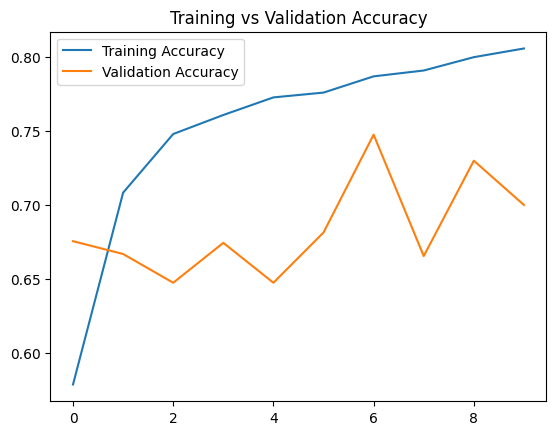

In [ ]:
# Plotting

acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

Much improvements than model 0 in balance between training (0.8) and validation accuracy (0.7)

Then, still overfitting and test the model with more neurons and padding.

### Model 2 (+ Padding)

In [ ]:
model_2 = Sequential([
  data_augmentation,

  layers.Rescaling(1./255),

  layers.Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3), padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(10, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Flatten(),

  layers.Dense(len(class_names), activation='softmax')
])

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


894/894 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.5661 - loss: 1.4231 - val_accuracy: 0.5821 - val_loss: 1.4648
Epoch 2/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.7156 - loss: 0.8971 - val_accuracy: 0.6684 - val_loss: 1.1108
Epoch 3/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.7591 - loss: 0.7548 - val_accuracy: 0.6062 - val_loss: 1.5626
Epoch 4/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - accuracy: 0.7826 - loss: 0.6830 - val_accuracy: 0.7360 - val_loss: 0.8875
Epoch 5/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.7956 - loss: 0.6385 - val_accuracy: 0.7344 - val_loss: 0.8943
Epoch 6/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.8017 - loss: 0.6197 - val_accuracy: 0.6859 - val_loss: 1.2697
Epoch 7/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.8139 - loss: 0.5785 - val_accuracy: 0.7061 - val_loss: 1.1006
Epoch 8/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - accuracy: 0.8179 - loss: 0.5718 - val_accurac

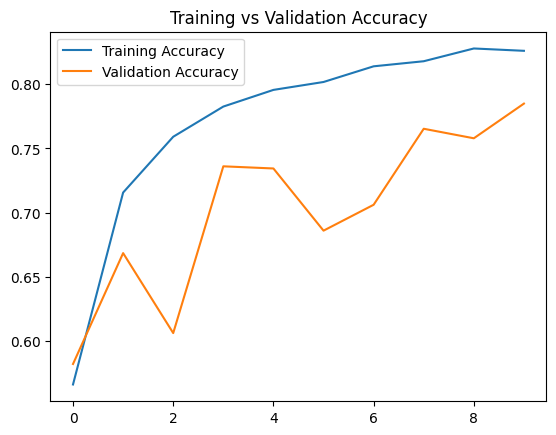

In [ ]:
# Plotting

acc = history_2.history['accuracy']
val_acc = history_2.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

Not that bad. But still overfit and accuracy needs more improvement with more neurons and Dropouts layers.

---

### Model 3 (+ Dropouts, + More neurons)


Add More Conv Layers + Increase Filters

In [ ]:
model_3 = Sequential([

  data_augmentation,

  layers.Rescaling(1./255),

  layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3), padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(64, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(128, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Flatten(),

  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),

  layers.Dense(len(class_names), activation='softmax')
])

model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


894/894 ━━━━━━━━━━━━━━━━━━━━ 72s 69ms/step - accuracy: 0.5894 - loss: 1.3257 - val_accuracy: 0.7311 - val_loss: 0.8227
Epoch 2/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 72s 65ms/step - accuracy: 0.7955 - loss: 0.6182 - val_accuracy: 0.7936 - val_loss: 0.6325
Epoch 3/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.8377 - loss: 0.4842 - val_accuracy: 0.8577 - val_loss: 0.4081
Epoch 4/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 62s 69ms/step - accuracy: 0.8717 - loss: 0.3819 - val_accuracy: 0.8448 - val_loss: 0.4740
Epoch 5/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.8883 - loss: 0.3261 - val_accuracy: 0.7906 - val_loss: 0.7126
Epoch 6/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 62s 69ms/step - accuracy: 0.8973 - loss: 0.3095 - val_accuracy: 0.8607 - val_loss: 0.4440
Epoch 7/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 78s 65ms/step - accuracy: 0.9088 - loss: 0.2700 - val_accuracy: 0.8634 - val_loss: 0.4750
Epoch 8/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.9204 - loss: 0.2363 - val_accurac

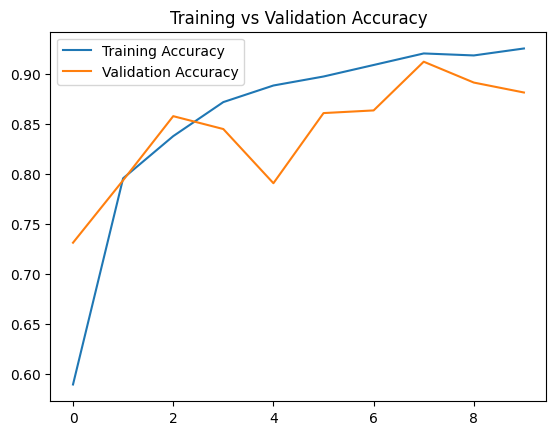

In [ ]:
# Plotting

acc = history_3.history['accuracy']
val_acc = history_3.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

So much improvement in both training (0.92) and validation (~0.9).

---

## Model 4 (+ GlobalPooling)

In [ ]:
model_4 = Sequential([

  data_augmentation,

  layers.Rescaling(1./255),

  layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3), padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(64, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(128, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.GlobalAveragePooling2D(),

  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),

  layers.Dense(len(class_names), activation='softmax')
])

model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_4 = model_4.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 54s 58ms/step - accuracy: 0.3565 - loss: 2.0857 - val_accuracy: 0.5283 - val_loss: 1.4291
Epoch 2/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 54s 60ms/step - accuracy: 0.6079 - loss: 1.2110 - val_accuracy: 0.6018 - val_loss: 1.1880
Epoch 3/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.6870 - loss: 0.9559 - val_accuracy: 0.6803 - val_loss: 0.9186
Epoch 4/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.7377 - loss: 0.8017 - val_accuracy: 0.7304 - val_loss: 0.8106
Epoch 5/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 84s 63ms/step - accuracy: 0.7632 - loss: 0.7161 - val_accuracy: 0.7356 - val_loss: 0.8026
Epoch 6/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 82s 63ms/step - accuracy: 0.7913 - loss: 0.6286 - val_accuracy: 0.8161 - val_loss: 0.5496
Epoch 7/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 82s 63ms/step - accuracy: 0.8081 - loss: 0.5730 - val_accuracy: 0.7629 - val_loss: 0.7366
Epoch 8/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 84s 65ms/step - accuracy: 0.8248 - loss: 0.5249 - 

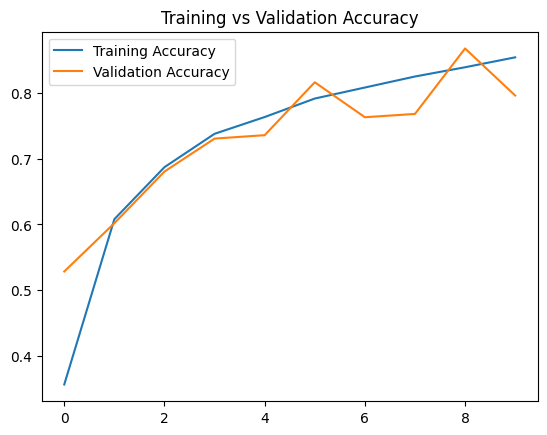

In [ ]:
# Plotting

acc = history_4.history['accuracy']
val_acc = history_4.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

GlobalPooling make not much improvement. Training (0.85) & Validation (~0.82).

---

## Model 5 (+ Batch Normalization)

In [ ]:
model_5 = Sequential([

  data_augmentation,

  layers.Rescaling(1./255),

  layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3), padding='same'),
  layers.BatchNormalization(),
  layers.MaxPool2D(),

  layers.Conv2D(64, 3, activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.MaxPool2D(),

  layers.Conv2D(128, 3, activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.MaxPool2D(),

  layers.GlobalAveragePooling2D(),

  layers.Dropout(0.4),

  layers.Dense(128, activation='relu'),

  layers.Dropout(0.3),


  layers.Dense(len(class_names), activation='softmax')
])

model_5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_5 = model_5.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


894/894 ━━━━━━━━━━━━━━━━━━━━ 115s 123ms/step - accuracy: 0.3766 - loss: 2.1323 - val_accuracy: 0.5633 - val_loss: 1.4521
Epoch 2/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 115s 128ms/step - accuracy: 0.5539 - loss: 1.4698 - val_accuracy: 0.5917 - val_loss: 1.3062
Epoch 3/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 115s 129ms/step - accuracy: 0.6182 - loss: 1.2257 - val_accuracy: 0.6424 - val_loss: 1.1512
Epoch 4/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 112s 125ms/step - accuracy: 0.6634 - loss: 1.0640 - val_accuracy: 0.5654 - val_loss: 1.5393
Epoch 5/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 115s 129ms/step - accuracy: 0.6904 - loss: 0.9678 - val_accuracy: 0.6361 - val_loss: 1.2654
Epoch 6/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 113s 126ms/step - accuracy: 0.7217 - loss: 0.8765 - val_accuracy: 0.7071 - val_loss: 0.9863
Epoch 7/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 115s 129ms/step - accuracy: 0.7415 - loss: 0.8054 - val_accuracy: 0.6980 - val_loss: 0.9681
Epoch 8/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - accuracy: 0.7628 - loss: 0.74

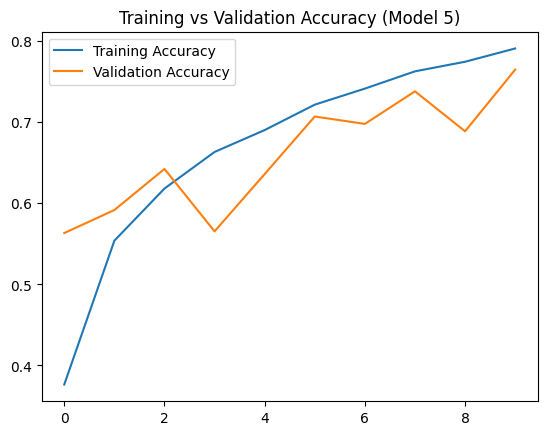

In [ ]:
acc = history_5.history['accuracy']
val_acc = history_5.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy (Model 5)")
plt.show()


Worse than previous models.

---


# Early Stopping

## Model 3 (+ Early Stopping)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    min_delta=0.001,
    restore_best_weights=True
)

In [ ]:
model_3 = Sequential([

  data_augmentation,

  layers.Rescaling(1./255),

  layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3), padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(64, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(128, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Flatten(),

  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),

  layers.Dense(len(class_names), activation='softmax')
])

model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_3_earlystop = model_3.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.5602 - loss: 1.4294 - val_accuracy: 0.6840 - val_loss: 0.9798
Epoch 2/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 60s 67ms/step - accuracy: 0.7578 - loss: 0.7354 - val_accuracy: 0.7838 - val_loss: 0.6637
Epoch 3/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 60s 67ms/step - accuracy: 0.8111 - loss: 0.5649 - val_accuracy: 0.8290 - val_loss: 0.5159
Epoch 4/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 60s 68ms/step - accuracy: 0.8522 - loss: 0.4499 - val_accuracy: 0.8686 - val_loss: 0.3924
Epoch 5/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 64s 72ms/step - accuracy: 0.8713 - loss: 0.3838 - val_accuracy: 0.8410 - val_loss: 0.4839
Epoch 6/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.8838 - loss: 0.3452 - val_accuracy: 0.8868 - val_loss: 0.3582
Epoch 7/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.8960 - loss: 0.3124 - val_accuracy: 0.8978 - val_loss: 0.3019
Epoch 8/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 64s 71ms/step - accuracy: 0.9024 - loss: 0.2829 - 

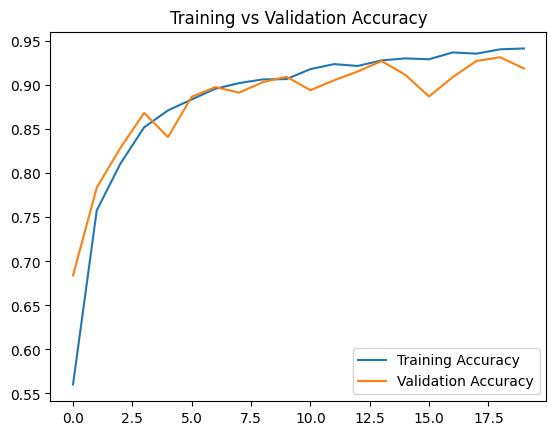

In [ ]:
acc = history_3_earlystop.history['accuracy']
val_acc = history_3_earlystop.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


### Evaluate model_3

In [ ]:
loss, accuracy = model_3.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9317 - loss: 0.1992
Validation Loss: 0.1991739571094513
Validation Accuracy: 0.9317004680633545


In [ ]:
val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_data = val_data.prefetch(buffer_size=AUTOTUNE)

Found 35725 files belonging to 23 classes.
Using 7145 files for validation.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

labels = np.arange(len(class_names))

# Predictions
y_pred_probs = model_3.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([y for x, y in val_data], axis=0)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.00      0.00      0.00         0
                                 Apple___Black_rot       0.00      0.00      0.00         0
                          Apple___Cedar_apple_rust       0.00      0.00      0.00         0
                                   Apple___healthy       0.00      0.00      0.00         0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.00      0.00      0.00         0
                       Corn_(maize)___Common_rust_       0.00      0.00      0.00         0
               Corn_(maize)___Northern_Leaf_Blight       0.00      0.00      0.00         0
                            Corn_(maize)___healthy       0.00      0.00      0.00         0
                     Pepper__bell___Bacterial_spot       0.00      0.00      0.00         0
                            Pepper__b

In [ ]:
print(len(class_names))
print(np.unique(y_true))
print(np.unique(y_pred))

23
[18 19 20 21 22]
[ 0  1  2  3  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


### Evaluation Error: Class Imbalance in training & validation sets

That's why Confusion matrix show some zero values in some classes.

---

## Model 4 (+ Early Stopping)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
model_4 = Sequential([

  data_augmentation,

  layers.Rescaling(1./255),

  layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3), padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(64, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(128, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.GlobalAveragePooling2D(),

  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),

  layers.Dense(len(class_names), activation='softmax')
])

model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_4_earlystop = model_4.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.2822 - loss: 2.3577 - val_accuracy: 0.4333 - val_loss: 1.7549
Epoch 2/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - accuracy: 0.5399 - loss: 1.4336 - val_accuracy: 0.6662 - val_loss: 1.0345
Epoch 3/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.6327 - loss: 1.1196 - val_accuracy: 0.7043 - val_loss: 0.8963
Epoch 4/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 54s 60ms/step - accuracy: 0.6865 - loss: 0.9629 - val_accuracy: 0.7369 - val_loss: 0.7887
Epoch 5/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.7185 - loss: 0.8526 - val_accuracy: 0.7923 - val_loss: 0.6355


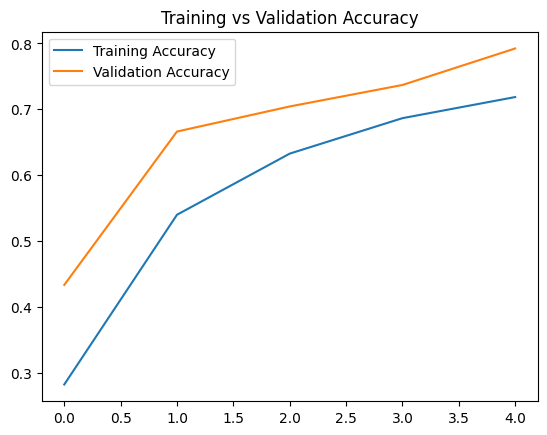

In [ ]:
acc = history_4_earlystop.history['accuracy']
val_acc = history_4_earlystop.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


In [ ]:
# # Clone the model
# # Use the same architecture
# model_3 = tf.keras.models.clone_model(model_1)

# # Compile the cloned model
# model_3.compile(loss="categorical_crossentropy",
#               optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#               metrics=["accuracy"])

# # Fit the model
# history_3 = model_3.fit(train_data, # use augmented data
#                         epochs=10,
#                         steps_per_epoch=len(train_data),
#                         validation_data=val_data,
#                         validation_steps=len(val_data))

# Debugging: Updated Data (+ Balanced Splitting)

## Split Data Manually (+ ChatGPt)

In [77]:
import tensorflow as tf
import numpy as np

from sklearn.model_selection import train_test_split

In [78]:
dataset_path = "/content/Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [79]:
image_paths = []
labels = []

class_names = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 23
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [80]:
# Assign labels
for label, class_name in enumerate(class_names):

    class_dir = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_dir):

        image_path = os.path.join(class_dir, image_name)

        image_paths.append(image_path)

        labels.append(label)

In [81]:
image_paths = np.array(image_paths)
labels = np.array(labels)

In [82]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=123
)

In [83]:
# Verify split

print("Train samples:", len(train_paths))
print("Validation samples:", len(val_paths))

print("Unique train labels:", len(np.unique(train_labels)))
print("Unique val labels:", len(np.unique(val_labels)))

Train samples: 28580
Validation samples: 7145
Unique train labels: 23
Unique val labels: 23


In [84]:
# Function to load images
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)

    return image, label

### Corrupted file

In [91]:
from PIL import Image
import os

bad_files = []

for path in image_paths:
    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_files.append(path)

print("Corrupted files:", len(bad_files))

for file in bad_files[:10]:
    print(file)

Corrupted files: 0


In [86]:
### Remove
for file in bad_files:
    os.remove(file)

**Create TensorFlow datasets**

Training dataset

In [87]:
train_data = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_data = train_data.map(load_image)

train_data = train_data.shuffle(1000)

train_data = train_data.batch(BATCH_SIZE)

train_data = train_data.prefetch(tf.data.AUTOTUNE)

Validation dataset

In [62]:
val_data = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_data = val_data.map(load_image)

val_data = val_data.batch(BATCH_SIZE)

val_data = val_data.prefetch(tf.data.AUTOTUNE)

In [88]:
# Verify split

y_true = np.concatenate(
    [y.numpy() for x, y in val_data],
    axis=0
)

print(np.unique(y_true))
print()
print(len(np.unique(y_true)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]

23


In [90]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)

## Updated Model 3

In [92]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    min_delta=0.001,
    restore_best_weights=True
)

In [93]:
model_3 = Sequential([

  data_augmentation,

  layers.Rescaling(1./255),

  layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3), padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(64, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(128, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Flatten(),

  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),

  layers.Dense(len(class_names), activation='softmax')
])

model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_3_earlystop = model_3.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


894/894 ━━━━━━━━━━━━━━━━━━━━ 72s 77ms/step - accuracy: 0.6387 - loss: 1.1595 - val_accuracy: 0.6730 - val_loss: 1.0918
Epoch 2/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.8148 - loss: 0.5691 - val_accuracy: 0.8245 - val_loss: 0.5486
Epoch 3/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 84s 77ms/step - accuracy: 0.8621 - loss: 0.4172 - val_accuracy: 0.8829 - val_loss: 0.3393
Epoch 4/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 78s 73ms/step - accuracy: 0.8830 - loss: 0.3534 - val_accuracy: 0.8922 - val_loss: 0.3341
Epoch 5/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 86s 78ms/step - accuracy: 0.9007 - loss: 0.2941 - val_accuracy: 0.8665 - val_loss: 0.4189
Epoch 6/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 71s 78ms/step - accuracy: 0.9081 - loss: 0.2697 - val_accuracy: 0.9072 - val_loss: 0.2697
Epoch 7/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 66s 73ms/step - accuracy: 0.9157 - loss: 0.2447 - val_accuracy: 0.8086 - val_loss: 0.6859
Epoch 8/20
894/894 ━━━━━━━━━━━━━━━━━━━━ 69s 76ms/step - accuracy: 0.9275 - loss: 0.2161 - val_accurac

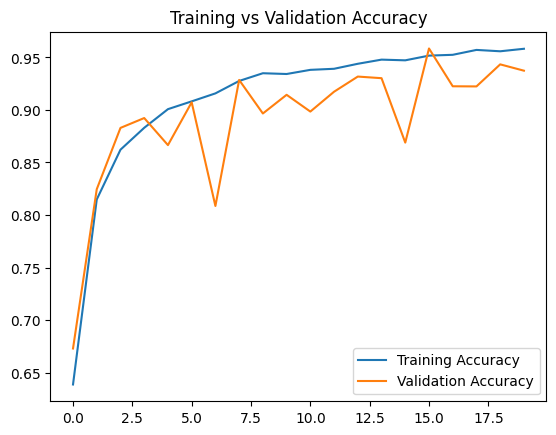

In [94]:
acc = history_3_earlystop.history['accuracy']
val_acc = history_3_earlystop.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

### Evaluate model_3 (debugged)

In [96]:
loss, accuracy = model_3.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

224/224 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9584 - loss: 0.1296
Validation Loss: 0.12961316108703613
Validation Accuracy: 0.9584382772445679


In [95]:
from sklearn.metrics import classification_report, confusion_matrix

labels = np.arange(len(class_names))

# Predictions
y_pred_probs = model_3.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([y for x, y in val_data], axis=0)

# Classification report
print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.93      0.96       403
                                 Apple___Black_rot       0.98      0.98      0.98       398
                          Apple___Cedar_apple_rust       0.98      0.99      0.99       352
                                   Apple___healthy       0.98      0.99      0.98       402
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.96      0.92       328
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       381
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.90      0.93       382
                            Corn_(maize)___healthy       0.99      1.00      0.99       372
                     Pepper__bell___Bacterial_spot       0.99      0.95      0.97       199
                            Pepper__b

Very Good perfomance of the model_3.

---

## Updated Model 4

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

In [ ]:
model_4 = Sequential([

  data_augmentation,

  layers.Rescaling(1./255),

  layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3), padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(64, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.Conv2D(128, 3, activation='relu', padding='same'),
  layers.MaxPool2D(),

  layers.GlobalAveragePooling2D(),

  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),

  layers.Dense(len(class_names), activation='softmax')
])

model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_4_earlystop = model_4.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

---

## **Notes**

Overall, model_3 is the best performance model with best and balanced accuracy in both training and validation.


Therefore, our final model is selected.

### Best Model (Save & Load)

In [97]:
model_3.save("plant_disease_classifier.h5")

In [98]:
loaded_model = tf.keras.models.load_model("plant_disease_classifier.h5")

### Predict a image

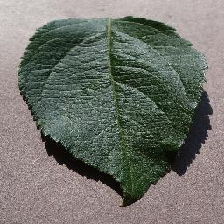

In [100]:
img_path = "/content/Dataset/Apple___healthy/00907d8b-6ae6-4306-bfd7-d54471981a86___RS_HL 5709_flipTB.JPG"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(224, 224)
)

img

In [101]:
# Convert to array
img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0)

In [102]:
# Predict

predicted_value = loaded_model.predict(img_array)

predicted_label = class_names[np.argmax(predicted_value)]

confidence = np.max(predicted_value)

print("Prediction:", predicted_label)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
Prediction: Apple___healthy
Confidence: 0.9999982


---

# Transfer learning (if necessary)

### Model 6 (+ Transfer Learning)

In [ ]:
# # Build Base model - EfficientNetB0 Model
# # EfficientNet, MobileNetV2, ResNet50

# base_model = tf.keras.applications.EfficientNetB0(
#     include_top=False,
#     weights='imagenet',
#     input_shape=(224,224,3)
# )

# base_model.trainable = False # Freeze layers

In [ ]:
# model_6 = Sequential([
#   data_augmentation,

#   layers.Rescaling(1./255),

#   layers.Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),

#   base_model,

#   layers.MaxPool2D(),

#   layers.Conv2D(10, 3, activation='relu'),

#   layers.MaxPool2D(),

#   layers.Flatten(),

#   layers.Dropout(0.3),

#   layers.Dense(len(class_names), activation='softmax')
# ])